# 🤖 K-Means Clustering — Let's Explore!
### A beginner-friendly notebook for high school students

---

## What is clustering? 🤔

Imagine you have a messy pile of socks and you want to sort them into groups by color.
You're doing **clustering** — putting similar things together without anyone telling you the rules!

**K-Means** is a super popular algorithm that does exactly this with data.

- You tell it **how many groups** you want (that's the "K")
- It figures out the best way to split your data into those groups
- No labels needed — it learns the patterns on its own!

Let's explore it step by step 🚀


---
## Step 1 — Import the tools we need 🛠️

In [ ]:
# These are the libraries we need
import numpy as np                          # math helper
import matplotlib.pyplot as plt             # for making charts
from sklearn.cluster import KMeans          # the K-Means algorithm!
from sklearn.datasets import make_blobs     # creates fake data for us to practice with

# This just makes our charts look nice in the notebook
%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 5)

print("✅ All libraries loaded! We're ready to go.")


✅ All libraries loaded! We're ready to go.


---
## Step 2 — Create some data to cluster 📊

We'll use `make_blobs()` to create fake 2D data.
Think of each point as a student with two test scores.


In [ ]:
# make_blobs creates fake "blob" shaped clusters for us
# n_samples = how many data points
# centers   = how many natural groups in the data
# cluster_std = how spread out each group is (smaller = tighter blobs)
# random_state = makes sure we all get the same data (like a seed for randomness)

X, true_labels = make_blobs(
    n_samples=150,
    centers=3,
    cluster_std=0.8,
    random_state=42
)

print("Shape of our data:", X.shape)
print("That means:", X.shape[0], "data points, each with", X.shape[1], "features (x and y coordinates)")
print()
print("First 5 points:")
print(X[:5])


Shape of our data: (150, 2)
That means: 150 data points, each with 2 features (x and y coordinates)

First 5 points:
[[-2.53785845 10.26600105]
 [-3.18057164  8.76691623]
 [-6.6548337  -7.37826921]
 [ 6.14882756  2.11283193]
 [-6.46759898 -6.46908083]]


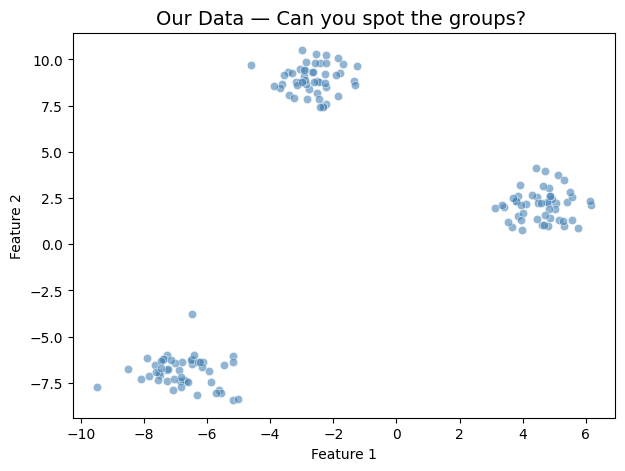

Can you see 3 groups just by looking? K-Means will find them automatically!


In [ ]:
# Let's plot the raw data BEFORE clustering
# Right now we don't know which group each point belongs to

plt.scatter(X[:, 0], X[:, 1], color='steelblue', alpha=0.6, edgecolors='white', linewidth=0.5)
plt.title("Our Data — Can you spot the groups? ", fontsize=14)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print("Can you see 3 groups just by looking? K-Means will find them automatically!")


---
## Step 3 — Run K-Means for the first time! 🎉

Here's the magic: just 3 lines of code to cluster our data.


In [ ]:
# ── Create the K-Means model ──
# n_clusters = how many groups we want (we'll try 3)
# random_state = so results are the same every time

kmeans = KMeans(n_clusters=3, random_state=42)

# ── Fit the model to our data ──
# This is where the algorithm actually runs and finds the groups!
kmeans.fit(X)

# ── Get the cluster label for each point ──
labels = kmeans.labels_

print("✅ K-Means finished running!")
print()
print("Labels assigned to first 15 points:", labels[:15])
print()
print("Each number (0, 1, 2) is a different cluster!")


✅ K-Means finished running!

Labels assigned to first 15 points: [0 0 1 2 1 2 0 0 1 2 1 1 2 1 2]

Each number (0, 1, 2) is a different cluster!


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


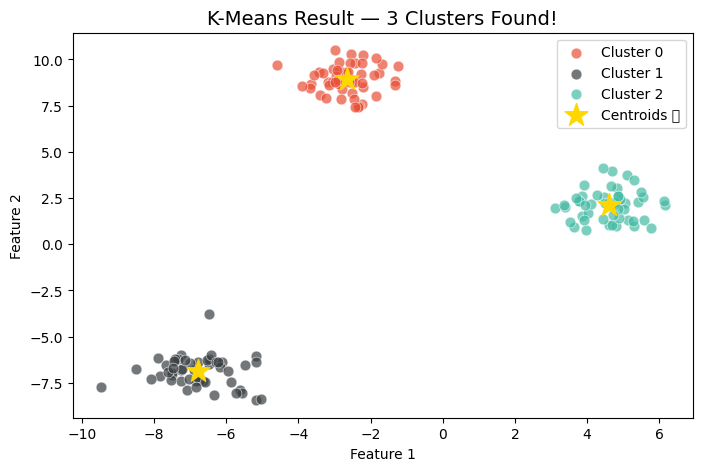

⭐ The gold stars are the CENTROIDS — the center point of each cluster.


In [ ]:
# Now let's plot the result — color each point by its cluster
colors = ['#E94F37', '#393E41', '#44BBA4']   # red, dark gray, teal

plt.figure(figsize=(8, 5))

for cluster_id in range(3):
    # Get all points belonging to this cluster
    mask = labels == cluster_id
    plt.scatter(X[mask, 0], X[mask, 1],
                color=colors[cluster_id],
                label=f'Cluster {cluster_id}',
                alpha=0.7, edgecolors='white', linewidth=0.5, s=60)

# Plot the centroids (the "center" of each cluster)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1],
            color='gold', marker='*', s=300, zorder=5, label='Centroids ⭐')

plt.title("K-Means Result — 3 Clusters Found!", fontsize=14)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

print("⭐ The gold stars are the CENTROIDS — the center point of each cluster.")


---
## Step 4 — Explore what K-Means gives us 🔍

After fitting, the `kmeans` object stores a lot of useful info!
Let's explore each one.


In [ ]:
# ── 1. cluster_centers_ ──
# The coordinates of each centroid (center point of each cluster)

print("📍 Centroid locations (cluster_centers_):")
print("  These are the 'average' position of all points in each cluster.")
print()
for i, center in enumerate(kmeans.cluster_centers_):
    print(f"  Cluster {i} center: x={center[0]:.2f}, y={center[1]:.2f}")


📍 Centroid locations (cluster_centers_):
  These are the 'average' position of all points in each cluster.

  Cluster 0 center: x=-2.66, y=8.93
  Cluster 1 center: x=-6.78, y=-6.89
  Cluster 2 center: x=4.60, y=2.11


In [ ]:
# ── 2. labels_ ──
# Which cluster each data point was assigned to

print("🏷️  labels_  — the cluster number for each data point:")
print()
print("First 20 labels:", kmeans.labels_[:20])
print()
print("Total points in each cluster:")
for i in range(3):
    count = (kmeans.labels_ == i).sum()
    print(f"  Cluster {i}: {count} points")


🏷️  labels_  — the cluster number for each data point:

First 20 labels: [0 0 1 2 1 2 0 0 1 2 1 1 2 1 2 0 1 0 2 2]

Total points in each cluster:
  Cluster 0: 50 points
  Cluster 1: 50 points
  Cluster 2: 50 points


In [ ]:
# ── 3. inertia_ ──
# SSE: sum of squared distances from each point to its centroid
# LOWER = clusters are tighter and more compact

print("📏 inertia_  — measures how tight the clusters are:")
print()
print(f"  Inertia = {kmeans.inertia_:.2f}")
print()
print("  Smaller inertia = tighter clusters (points are closer to their center)")
print("  Larger inertia  = looser clusters (points are more spread out)")


📏 inertia_  — measures how tight the clusters are:

  Inertia = 181.50

  Smaller inertia = tighter clusters (points are closer to their center)
  Larger inertia  = looser clusters (points are more spread out)


In [ ]:
# ── 4. n_iter_ ──
# How many times the algorithm went through the assign → update loop

print("🔄 n_iter_  — how many iterations K-Means needed:")
print()
print(f"  K-Means ran {kmeans.n_iter_} iterations before it converged.")
print()
print("  'Converged' means no points changed cluster — it found a stable answer!")


🔄 n_iter_  — how many iterations K-Means needed:

  K-Means ran 2 iterations before it converged.

  'Converged' means no points changed cluster — it found a stable answer!


---
## Step 5 — Predict which cluster a NEW point belongs to 🆕

Once K-Means is trained, you can ask it to classify brand new points!


In [ ]:
# Let's create 3 new mystery points and ask K-Means which cluster they belong to
new_points = np.array([
    [0, 0],     # mystery point 1
    [5, 5],     # mystery point 2
    [-3, 3],    # mystery point 3
])

# predict() tells us which cluster each new point belongs to
predictions = kmeans.predict(new_points)

print("🆕 New points and their predicted clusters:")
print()
for i, (point, cluster) in enumerate(zip(new_points, predictions)):
    print(f"  Point {i+1} at ({point[0]}, {point[1]}) → Cluster {cluster}")


🆕 New points and their predicted clusters:

  Point 1 at (0, 0) → Cluster 2
  Point 2 at (5, 5) → Cluster 2
  Point 3 at (-3, 3) → Cluster 0


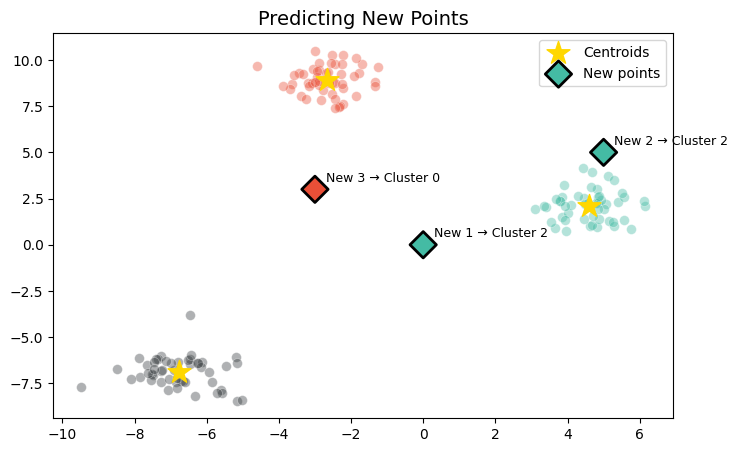

In [ ]:
# Let's visualize the new points on the plot
plt.figure(figsize=(8, 5))

# Original clustered data
for cluster_id in range(3):
    mask = labels == cluster_id
    plt.scatter(X[mask, 0], X[mask, 1],
                color=colors[cluster_id], alpha=0.4,
                edgecolors='white', linewidth=0.5, s=50)

# Centroids
plt.scatter(centers[:, 0], centers[:, 1],
            color='gold', marker='*', s=300, zorder=5, label='Centroids')

# New points
plt.scatter(new_points[:, 0], new_points[:, 1],
            color=[colors[p] for p in predictions],
            marker='D', s=180, zorder=6, edgecolors='black', linewidth=2, label='New points')

for i, (point, pred) in enumerate(zip(new_points, predictions)):
    plt.annotate(f'New {i+1} → Cluster {pred}',
                 xy=(point[0], point[1]),
                 xytext=(point[0]+0.3, point[1]+0.4),
                 fontsize=9, color='black',
                 arrowprops=dict(arrowstyle='->', color='gray'))

plt.title("Predicting New Points", fontsize=14)
plt.legend()
plt.show()


---
## Step 6 — What happens when we change K? 🎛️

K is the number of clusters you ask for.
Let's see what happens with different values of K!


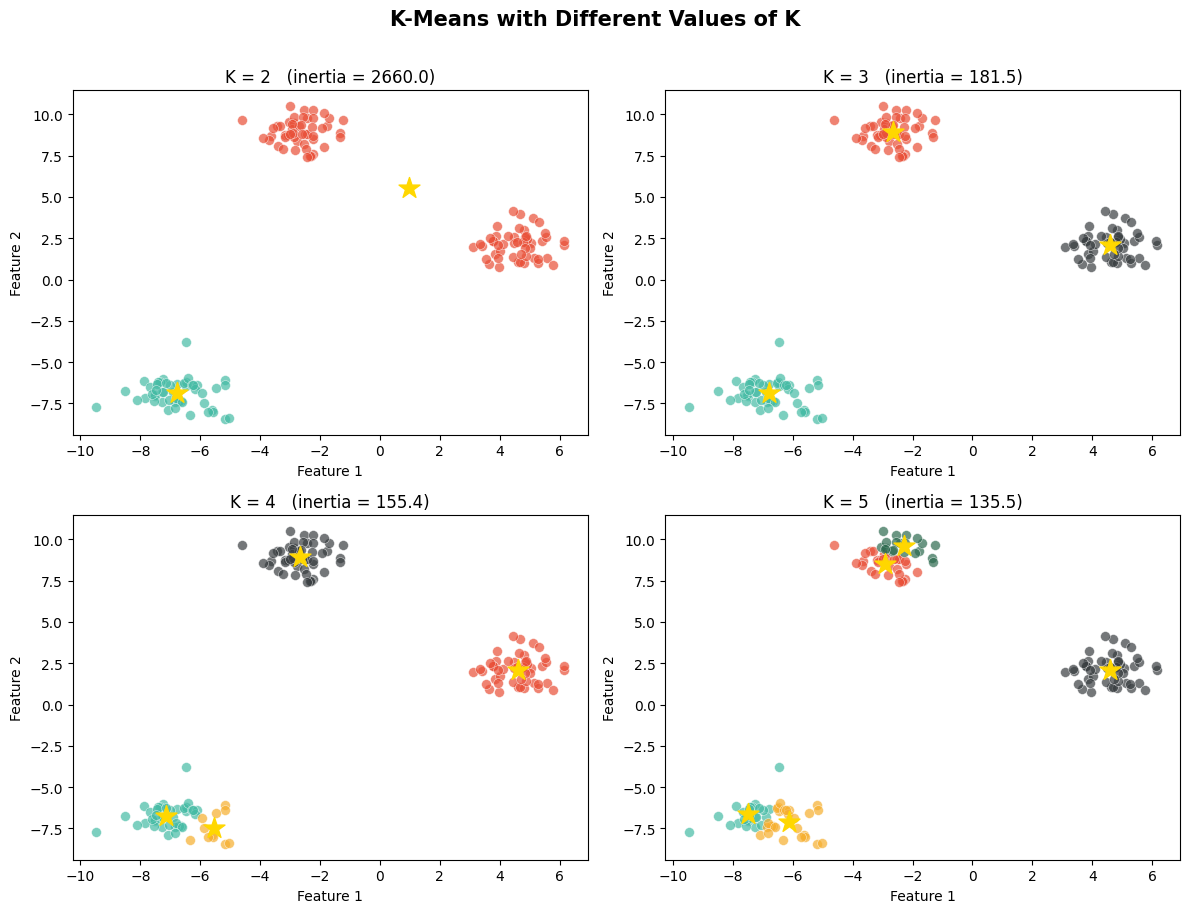

💡 Notice: as K gets bigger, the clusters get smaller and tighter (lower inertia).
   But that doesn't always mean it's better — sometimes you're just over-splitting!


In [ ]:
# Run K-Means with K = 2, 3, 4, and 5
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
k_values = [2, 3, 4, 5]

all_colors = ['#E94F37', '#44BBA4', '#393E41', '#F6AE2D', '#2D6A4F']

for ax, k in zip(axes.flatten(), k_values):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    lbl = km.labels_

    for cid in range(k):
        mask = lbl == cid
        ax.scatter(X[mask, 0], X[mask, 1],
                   color=all_colors[cid], alpha=0.7,
                   edgecolors='white', linewidth=0.4, s=50)

    # Centroids
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               color='gold', marker='*', s=250, zorder=5)

    ax.set_title(f"K = {k}   (inertia = {km.inertia_:.1f})", fontsize=12)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.suptitle("K-Means with Different Values of K", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("💡 Notice: as K gets bigger, the clusters get smaller and tighter (lower inertia).")
print("   But that doesn't always mean it's better — sometimes you're just over-splitting!")


---
## Step 7 — Finding the best K with the Elbow Method 📐

The big question: **how do you choose K?**

One popular trick is the **Elbow Method**:
- Run K-Means for many values of K
- Plot the inertia for each
- Find where the line "bends like an elbow" — that's usually a good K!


In [ ]:
# Try K = 1 through 10 and record the inertia each time
k_range = range(1, 11)
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)
    print(f"  K={k:2d}  →  inertia = {km.inertia_:.1f}")


  K= 1  →  inertia = 9788.9
  K= 2  →  inertia = 2660.0
  K= 3  →  inertia = 181.5
  K= 4  →  inertia = 155.4
  K= 5  →  inertia = 135.5
  K= 6  →  inertia = 113.9
  K= 7  →  inertia = 98.7
  K= 8  →  inertia = 84.7
  K= 9  →  inertia = 73.1
  K=10  →  inertia = 67.1


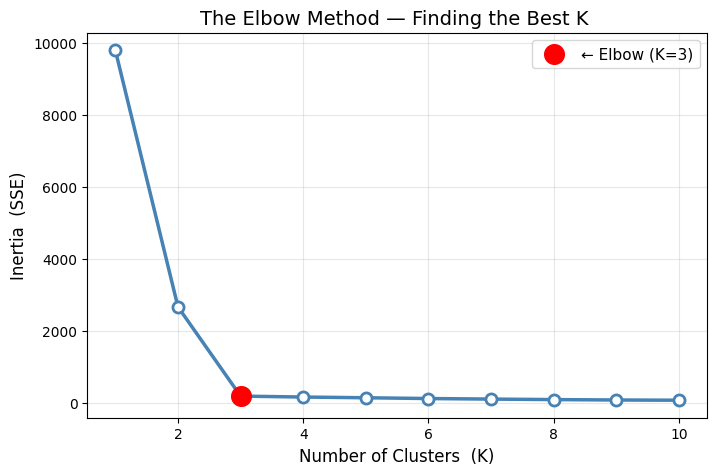

The 'elbow' is at K=3 — that's where adding more clusters stops helping much.
   The line drops steeply before K=3, then flattens out after it.


In [ ]:
# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker='o', color='steelblue',
         linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)

# Highlight the elbow point (K=3 for our data)
plt.scatter([3], [inertias[2]], color='red', s=200, zorder=5, label='← Elbow (K=3)')

plt.xlabel("Number of Clusters  (K)", fontsize=12)
plt.ylabel("Inertia  (SSE)", fontsize=12)
plt.title("The Elbow Method — Finding the Best K ", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print("The 'elbow' is at K=3 — that's where adding more clusters stops helping much.")
print("   The line drops steeply before K=3, then flattens out after it.")


---
## Step 8 — Explore KMeans parameters 🎮

The `KMeans()` function has several settings you can change.
Let's explore the most important ones!


In [ ]:
# ─── Parameter: random_state ───────────────────────────────────────────────
# K-Means starts from RANDOM positions.
# random_state fixes the random starting point so you get the same result every time.

print("🎲 What happens without random_state fixed?")
print()

for seed in [0, 1, 2, 3, 4]:
    km = KMeans(n_clusters=3, n_init=1, random_state=seed)
    km.fit(X)
    print(f"  random_state={seed}  →  inertia = {km.inertia_:.2f}")

print()
print("Notice: different seeds can give slightly different inertia values!")
print("That's why we use n_init > 1 — to run many times and pick the best result.")


🎲 What happens without random_state fixed?

  random_state=0  →  inertia = 181.50
  random_state=1  →  inertia = 181.50
  random_state=2  →  inertia = 181.50
  random_state=3  →  inertia = 181.50
  random_state=4  →  inertia = 181.50

Notice: different seeds can give slightly different inertia values!
That's why we use n_init > 1 — to run many times and pick the best result.


In [ ]:
# ─── Parameter: n_init ─────────────────────────────────────────────────────
# n_init = how many times K-Means re-runs with different starting points
# It keeps the BEST result (lowest inertia)

print("🔁 Comparing n_init values:")
print()

for n in [1, 3, 10]:
    km = KMeans(n_clusters=3, n_init=n, random_state=42)
    km.fit(X)
    print(f"  n_init={n:2d}  →  inertia = {km.inertia_:.2f}  "
          f"  (ran the algorithm {n} time(s), kept the best)")

print()
print("💡 n_init=10 is the default — a good balance of speed and reliability.")


🔁 Comparing n_init values:

  n_init= 1  →  inertia = 181.50    (ran the algorithm 1 time(s), kept the best)
  n_init= 3  →  inertia = 181.50    (ran the algorithm 3 time(s), kept the best)
  n_init=10  →  inertia = 181.50    (ran the algorithm 10 time(s), kept the best)

💡 n_init=10 is the default — a good balance of speed and reliability.


In [ ]:
# ─── Parameter: max_iter ────────────────────────────────────────────────────
# max_iter = the maximum number of assign → update cycles allowed
# Usually K-Means converges (stops changing) well before this limit.

print("🔄 Comparing max_iter values:")
print()

for m in [1, 5, 10, 300]:
    km = KMeans(n_clusters=3, max_iter=m, random_state=42, n_init=10)
    km.fit(X)
    print(f"  max_iter={m:4d}  →  inertia = {km.inertia_:.2f}  "
          f"  (actually ran {km.n_iter_} iterations)")

print()
print("💡 Default is max_iter=300. For most data, K-Means converges in < 20 iterations!")


🔄 Comparing max_iter values:

  max_iter=   1  →  inertia = 181.50    (actually ran 1 iterations)
  max_iter=   5  →  inertia = 181.50    (actually ran 2 iterations)
  max_iter=  10  →  inertia = 181.50    (actually ran 2 iterations)
  max_iter= 300  →  inertia = 181.50    (actually ran 2 iterations)

💡 Default is max_iter=300. For most data, K-Means converges in < 20 iterations!


In [ ]:
# ─── Parameter: init ────────────────────────────────────────────────────────
# init = the strategy for choosing starting centroid positions
# 'k-means++' is smarter than pure random — it spreads them out automatically

print("🚀 Comparing init strategies:")
print()

for init in ['random', 'k-means++']:
    results = []
    for seed in range(20):
        km = KMeans(n_clusters=3, init=init, n_init=1, random_state=seed)
        km.fit(X)
        results.append(km.inertia_)

    print(f"  init='{init}':")
    print(f"    Best  inertia across 20 runs: {min(results):.2f}")
    print(f"    Worst inertia across 20 runs: {max(results):.2f}")
    print(f"    Spread (worst - best):        {max(results)-min(results):.2f}")
    print()

print("💡 'k-means++' gives more consistent results — less spread between best and worst.")
print("   It's the default in scikit-learn, so you don't need to set it manually.")


🚀 Comparing init strategies:

  init='random':
    Best  inertia across 20 runs: 181.50
    Worst inertia across 20 runs: 2640.84
    Spread (worst - best):        2459.33

  init='k-means++':
    Best  inertia across 20 runs: 181.50
    Worst inertia across 20 runs: 181.50
    Spread (worst - best):        0.00

💡 'k-means++' gives more consistent results — less spread between best and worst.
   It's the default in scikit-learn, so you don't need to set it manually.


---
## Step 9 — Quick summary cheatsheet 📋

Here's everything you learned about `KMeans` in sklearn:


In [ ]:
# KMeans Quick Cheatsheet
print("=" * 60)
print("  KMeans Cheatsheet")
print("=" * 60)
print()
print("CREATE:")
print("  km = KMeans(n_clusters=3,     # how many groups?")
print("              init='k-means++', # smart starting positions")
print("              n_init=10,        # run 10x, keep best")
print("              random_state=42)  # same result every time")
print()
print("FIT (train the model):")
print("  km.fit(X)")
print()
print("AFTER FITTING:")
print("  km.labels_           -> cluster number for each point")
print("  km.cluster_centers_  -> center (x,y) of each cluster")
print("  km.inertia_          -> SSE: how tight the clusters are")
print("  km.n_iter_           -> how many iterations it took")
print()
print("PREDICT new data:")
print("  km.predict(new_X)    -> cluster number for new points")
print("=" * 60)


  KMeans Cheatsheet

CREATE:
  km = KMeans(n_clusters=3,     # how many groups?
              init='k-means++', # smart starting positions
              n_init=10,        # run 10x, keep best
              random_state=42)  # same result every time

FIT (train the model):
  km.fit(X)

AFTER FITTING:
  km.labels_           -> cluster number for each point
  km.cluster_centers_  -> center (x,y) of each cluster
  km.inertia_          -> SSE: how tight the clusters are
  km.n_iter_           -> how many iterations it took

PREDICT new data:
  km.predict(new_X)    -> cluster number for new points


---
## 🏆 Your Turn — Mini Challenges!

Try these on your own. Change the code, run it, and see what happens!


In [ ]:
# ── Challenge 1 ────────────────────────────────────────────────────────────
# Create a new dataset with 5 clusters and 300 points.
# Run K-Means with the correct K and plot the result.

# YOUR CODE HERE ↓



In [ ]:
# ── Challenge 2 ────────────────────────────────────────────────────────────
# The dataset below has blobs that are more spread out (cluster_std=2.0).
# Run the elbow method on it. Does the elbow still appear at K=3?

X2, _ = make_blobs(n_samples=200, centers=3, cluster_std=2.0, random_state=7)

# YOUR CODE HERE ↓
# Hint: copy the elbow method code from Step 7



In [ ]:
# ── Challenge 3 ────────────────────────────────────────────────────────────
# What is the inertia when K = number of data points?
# (Every point is its own cluster, so every point IS the centroid)
# Try it with a small dataset of 10 points.

X_small, _ = make_blobs(n_samples=10, centers=3, random_state=42)

# YOUR CODE HERE ↓
# Hint: set n_clusters = 10 (the number of points)
# What do you expect inertia_ to be? Why?



In [ ]:
# ── Bonus Challenge ─────────────────────────────────────────────────────────
# Load the Iris dataset (real flower measurements!) and cluster it.
# Then compare your K-Means clusters to the true species labels.

from sklearn.datasets import load_iris
from sklearn.metrics import adjusted_rand_score

iris = load_iris()
X_iris = iris.data        # 4 measurements per flower (don't use labels to train!)
y_iris = iris.target      # true species: 0=setosa, 1=versicolor, 2=virginica

# YOUR CODE HERE ↓
# 1. Fit KMeans with n_clusters=3 on X_iris
# 2. Print the cluster labels
# 3. Check how well it matches true species:
#    score = adjusted_rand_score(y_iris, your_labels)
#    (1.0 = perfect match, 0.0 = random)

